<a href="https://colab.research.google.com/github/thiranesh/Thiranesh-codeboosters-2026/blob/main/day-5/Thiranesh_day_5_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd

# API details
API_KEY = 'f93e5d4a1dc43dd0f13a34d059136b16'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Coimbatore',
    'New York',
    'Tokyo',
    'Paris',
    'Dubai',
    'Singapore',
    'Sydney',
    'Toronto'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):

    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """

    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:

        response = requests.get(
            BASE_URL,
            params=params,
            timeout=10
        )

        if response.status_code == 200:

            data = response.json()

            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }

        else:

            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")

            return None

    except requests.exceptions.RequestException as e:

        print(f"Request failed: {e}")

        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:

    print(f"Fetching weather for {city}...", end=' ')

    record = fetch_weather(city, API_KEY)

    if record:

        weather_records.append(record)

        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )

    else:

        print("Failed")


# Final Output
print("\nWeather Records:\n")

for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Coimbatore... 33.88°C, few clouds
Fetching weather for New York... 13.87°C, scattered clouds
Fetching weather for Tokyo... 25.32°C, few clouds
Fetching weather for Paris... 28.67°C, clear sky
Fetching weather for Dubai... 38.96°C, clear sky
Fetching weather for Singapore... 32.11°C, broken clouds
Fetching weather for Sydney... 14.39°C, clear sky
Fetching weather for Toronto... 9.37°C, clear sky

Weather Records:

{'city': 'Coimbatore', 'temperature': 33.88, 'description': 'few clouds', 'icon': '02d', 'humidity': 49, 'wind_speed': 4.63, 'pressure': 1009, 'visibility': 7000, 'sunrise': 1780100902, 'sunset': 1780146673}
{'city': 'New York', 'temperature': 13.87, 'description': 'scattered clouds', 'icon': '03n', 'humidity': 49, 'wind_speed': 9.77, 'pressure': 1006, 'visibility': 10000, 'sunrise': 1780133293, 'sunset': 1780186757}
{'city': 'Tokyo', 'temperature': 25.32, 'description': 'few clouds', 'icon': '02d', 'humidity': 58, 'wind_speed': 9.2

In [ ]:
df = pd.DataFrame(weather_records)

print("DataFrame Head:")
print(df.head())

print("\nDataFrame Columns:")
print(df.columns)

print("\nDataFrame Info:")
df.info()

print("\nDataFrame Description:")
print(df.describe())

DataFrame Head:
         city  temperature       description icon  humidity  wind_speed  \
0  Coimbatore        33.88        few clouds  02d        49        4.63   
1    New York        13.87  scattered clouds  03n        49        9.77   
2       Tokyo        25.32        few clouds  02d        58        9.26   
3       Paris        28.67         clear sky  01d        52        1.03   
4       Dubai        38.96         clear sky  01d        24        3.60   

   pressure  visibility     sunrise      sunset  
0      1009        7000  1780100902  1780146673  
1      1006       10000  1780133293  1780186757  
2      1009       10000  1780082870  1780134595  
3      1020       10000  1780113206  1780170190  
4      1004       10000  1780104543  1780153431  

DataFrame Columns:
Index(['city', 'temperature', 'description', 'icon', 'humidity', 'wind_speed',
       'pressure', 'visibility', 'sunrise', 'sunset'],
      dtype='object')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Ra

In [ ]:
# 1. Identify missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# 2. Handle null records (if any - based on info() output, there aren't explicit NaNs)
# If there were NaNs, we could use df.dropna() or df.fillna() but it's not needed here.

# 3. Remove duplicate entries
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"\nNumber of duplicate rows removed: {initial_rows - len(df)}")

# 4. Ensure all columns contain valid data types
# Convert 'sunrise' and 'sunset' Unix timestamps to readable datetime objects
df['sunrise'] = pd.to_datetime(df['sunrise'], unit='s')
df['sunset'] = pd.to_datetime(df['sunset'], unit='s')

print("\nDataFrame Info after cleaning and type conversion:")
df.info()

print("\nFirst 5 rows after cleaning:")
print(df.head())


Missing values before cleaning:
city           0
temperature    0
description    0
icon           0
humidity       0
wind_speed     0
pressure       0
visibility     0
sunrise        0
sunset         0
dtype: int64

Number of duplicate rows removed: 0

DataFrame Info after cleaning and type conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   city         8 non-null      object        
 1   temperature  8 non-null      float64       
 2   description  8 non-null      object        
 3   icon         8 non-null      object        
 4   humidity     8 non-null      int64         
 5   wind_speed   8 non-null      float64       
 6   pressure     8 non-null      int64         
 7   visibility   8 non-null      int64         
 8   sunrise      8 non-null      datetime64[ns]
 9   sunset       8 non-null      datetime64[ns]
dtypes

In [ ]:
# Function to calculate Heat Index using the Steadman formula (NWS simplified version)
# This formula requires temperature in Fahrenheit and relative humidity in percentage.

def calculate_heat_index(temperature_celsius, humidity):
    # Convert temperature from Celsius to Fahrenheit
    temperature_fahrenheit = (temperature_celsius * 9/5) + 32

    # Steadman's Heat Index formula (NWS Simplified version)
    HI = -42.379 + 2.04901523 * temperature_fahrenheit + 10.14333127 * humidity - \
         0.22475541 * temperature_fahrenheit * humidity - 6.83783e-3 * temperature_fahrenheit**2 - \
         5.481717e-2 * humidity**2 + 1.22874e-3 * temperature_fahrenheit**2 * humidity + \
         8.5282e-4 * temperature_fahrenheit * humidity**2 - 1.99e-6 * temperature_fahrenheit**2 * humidity**2

    return HI

# Apply the function to create the 'heat_index' feature
df['heat_index'] = df.apply(lambda row: calculate_heat_index(row['temperature'], row['humidity']), axis=1)

print("DataFrame with new 'heat_index' feature:")
print(df[['city', 'temperature', 'humidity', 'heat_index']].head())

DataFrame with new 'heat_index' feature:
         city  temperature  humidity  heat_index
0  Coimbatore        33.88        49  100.047033
1    New York        13.87        49   86.718308
2       Tokyo        25.32        58   79.223778
3       Paris        28.67        52   85.040446
4       Dubai        38.96        24  102.331261


In [ ]:
import sqlite3

# Create connection
conn = sqlite3.connect('weather.db')

# Store dataframe into SQLite
df.to_sql(
    'weather_data',
    conn,
    if_exists='replace',
    index=False
)

print("Data stored successfully!")

# Verify data
result = pd.read_sql(
    "SELECT * FROM weather_data",
    conn
)

print(result.head())

Data stored successfully!
         city  temperature       description icon  humidity  wind_speed  \
0  Coimbatore        33.88        few clouds  02d        49        4.63   
1    New York        13.87  scattered clouds  03n        49        9.77   
2       Tokyo        25.32        few clouds  02d        58        9.26   
3       Paris        28.67         clear sky  01d        52        1.03   
4       Dubai        38.96         clear sky  01d        24        3.60   

   pressure  visibility              sunrise               sunset  heat_index  
0      1009        7000  2026-05-30 00:28:22  2026-05-30 13:11:13  100.047033  
1      1006       10000  2026-05-30 09:28:13  2026-05-31 00:19:17   86.718308  
2      1009       10000  2026-05-29 19:27:50  2026-05-30 09:49:55   79.223778  
3      1020       10000  2026-05-30 03:53:26  2026-05-30 19:43:10   85.040446  
4      1004       10000  2026-05-30 01:29:03  2026-05-30 15:03:51  102.331261  


In [ ]:
query = """
SELECT COUNT(*) AS total_cities
FROM weather_data;
"""

pd.read_sql(query, conn)

,total_cities
0,8


In [ ]:
query = """
SELECT city, temperature
FROM weather_data
ORDER BY temperature DESC
LIMIT 1;
"""

pd.read_sql(query, conn)

,city,temperature
0,Dubai,38.96


In [ ]:
query = """
SELECT city, temperature
FROM weather_data
ORDER BY temperature ASC
LIMIT 1;
"""

pd.read_sql(query, conn)

,city,temperature
0,Toronto,9.37


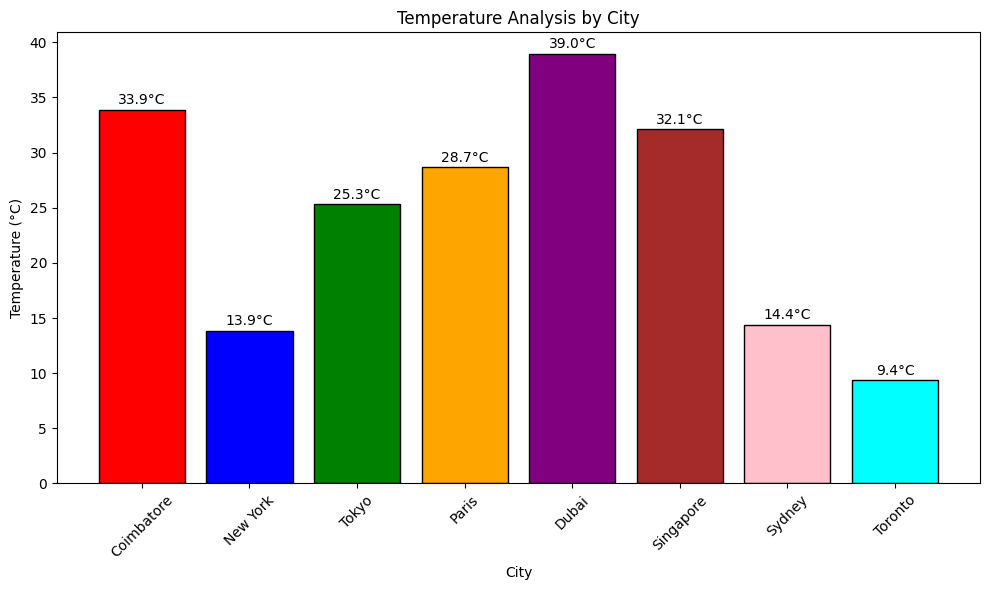

In [ ]:
import matplotlib.pyplot as plt

colors = [
    'red',
    'blue',
    'green',
    'orange',
    'purple',
    'brown',
    'pink',
    'cyan'
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    temp_df['city'],
    temp_df['temperature'],
    color=colors,          # <-- Add this line
    edgecolor='black'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}°C',
        ha='center'
    )

plt.title('Temperature Analysis by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

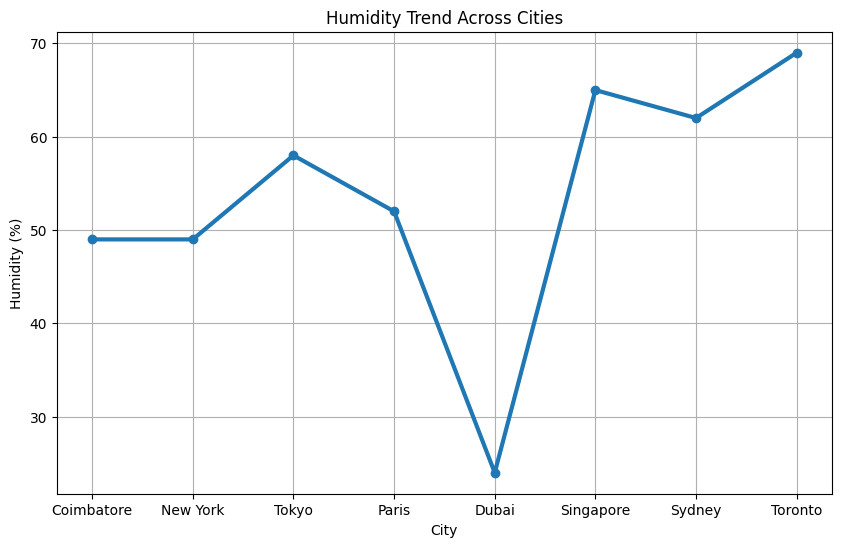

In [ ]:
query = """
SELECT city, humidity
FROM weather_data
"""

humidity_df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

plt.plot(
    humidity_df['city'],
    humidity_df['humidity'],
    marker='o',
    linewidth=3
)

plt.title('Humidity Trend Across Cities')
plt.xlabel('City')
plt.ylabel('Humidity (%)')

plt.grid(True)

plt.show()

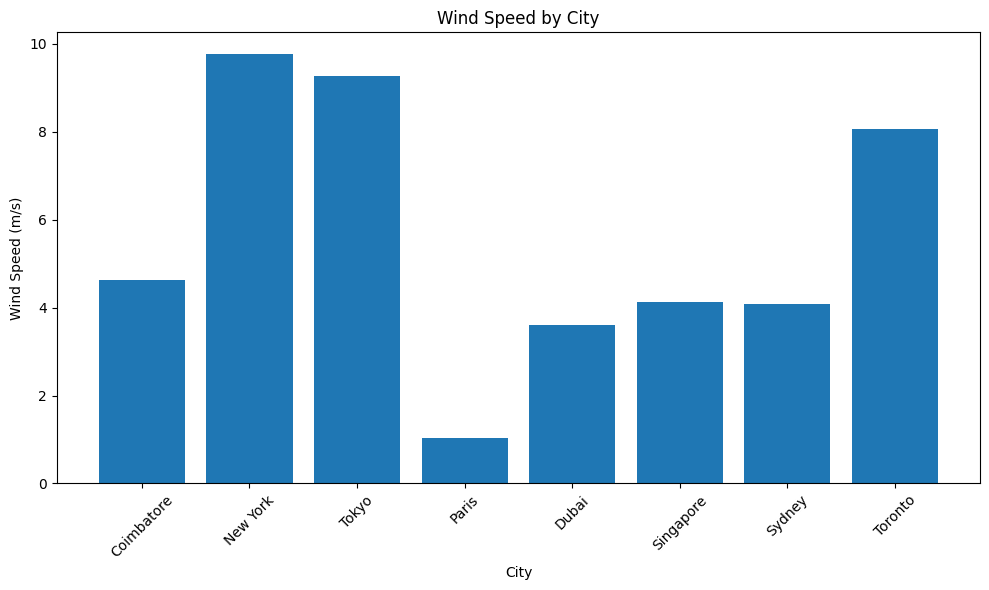

In [ ]:
query = """
SELECT city, wind_speed
FROM weather_data
"""

wind_df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))
plt.bar(
    wind_df['city'],
    wind_df['wind_speed']
)

plt.title('Wind Speed by City')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Select features and target variable
X = df[['temperature', 'wind_speed']]
y = df['humidity']

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} records")
print(f"Test set size: {len(X_test)} records\n")

# 3. Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.\n")

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation:\n")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}\n")

# 6. Compare actual vs. predicted humidity values
comparison_df = pd.DataFrame({'Actual Humidity': y_test, 'Predicted Humidity': y_pred})
print("Actual vs. Predicted Humidity (Test Set):\n")
print(comparison_df)

Training set size: 6 records
Test set size: 2 records

Model training complete.

Model Evaluation:

Mean Absolute Error (MAE): 19.99
Mean Squared Error (MSE): 401.57
Root Mean Squared Error (RMSE): 20.04
R-squared (R2): -5.27

Actual vs. Predicted Humidity (Test Set):

   Actual Humidity  Predicted Humidity
1               49           67.663247
5               65           43.673318
